# Assignment 3 - ANN Part

This notebook implements the Artificial Neural Network (ANN) part for the BBC news article classification assignment.

The goal is to classify BBC news articles into two classes using a Scikit-learn ANN model.  
The main evaluation metric is **macro F1-score**.

This notebook covers:
1. Loading the training and test datasets  
2. Text representation using TF-IDF  
3. Building an ANN classifier using `MLPClassifier`  
4. Tuning ANN hyperparameters using 5-fold stratified cross-validation  
5. Evaluating the final ANN model on the test set  
6. Summarising the effect of ANN hyperparameters

In [1]:
# If the required packages are not installed, uncomment and run this line:
# %pip install pandas numpy matplotlib scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score

## 1. Load the dataset

The dataset contains preprocessed BBC news articles.  
Each row contains a news article and its class label.

In [3]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

train_df.head()

,Id,Article,Category
0,1976,lifestyle governs mobile choice faster better ...,tech
1,1797,french honour director parker british film dir...,entertainment
2,1866,fockers fuel festive film chart comedy meet fo...,entertainment
3,1153,housewives lift channel 4 ratings debut us tel...,entertainment
4,342,u2 desire number one u2 three prestigious gram...,entertainment


In [4]:
print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

print("\nTraining columns:")
print(train_df.columns)

print("\nTest columns:")
print(test_df.columns)

Training set shape: (428, 3)
Test set shape: (106, 3)

Training columns:
Index(['Id', 'Article', 'Category'], dtype='str')

Test columns:
Index(['Id', 'Article', 'Category'], dtype='str')


## 2. Check class distribution

Before training the ANN model, we check the class distribution in both the training and test sets.  
This helps us understand whether the dataset is balanced.

In [5]:
print("Training class distribution:")
print(train_df["Category"].value_counts())

print("\nTest class distribution:")
print(test_df["Category"].value_counts())

Training class distribution:
Category
tech             216
entertainment    212
Name: count, dtype: int64

Test class distribution:
Category
entertainment    61
tech             45
Name: count, dtype: int64


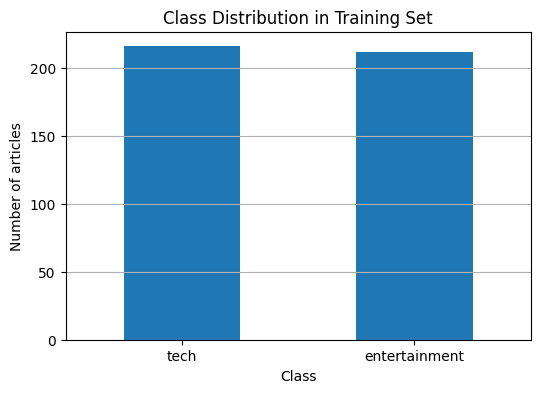

In [6]:
plt.figure(figsize=(6, 4))
train_df["Category"].value_counts().plot(kind="bar")
plt.xlabel("Class")
plt.ylabel("Number of articles")
plt.title("Class Distribution in Training Set")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

## 3. Prepare features and labels

The input feature is the article text.  
The target variable is the article category.

The category labels are encoded into numerical labels because Scikit-learn classifiers require numerical target values.

In [7]:
X_train_text = train_df["Article"]
X_test_text = test_df["Article"]

encoder = LabelEncoder()
y_train = encoder.fit_transform(train_df["Category"])
y_test = encoder.transform(test_df["Category"])

print("Classes:", encoder.classes_)
print("Number of training examples:", len(X_train_text))
print("Number of test examples:", len(X_test_text))

Classes: ['entertainment' 'tech']
Number of training examples: 428
Number of test examples: 106


## 4. ANN model and text representation

The articles are represented using TF-IDF features.  
The ANN classifier is implemented using Scikit-learn's `MLPClassifier`.

A `Pipeline` is used to combine TF-IDF vectorisation and ANN classification.  
This is important because during cross-validation, the TF-IDF vectoriser should only be fitted on the training fold, not on the validation fold.  
This avoids data leakage and gives a more reliable cross-validation estimate.

In [8]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

base_ann_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=2000)),
    ("ann", MLPClassifier(
        hidden_layer_sizes=(20,),
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        alpha=0.0001,
        max_iter=500,
        early_stopping=True,
        random_state=42
    ))
])

## 5. Hyperparameter tuning for ANN

Two important ANN hyperparameters are investigated:

- `hidden_layer_sizes`: controls the number of neurons in the hidden layer.  
  A larger hidden layer gives the model higher capacity, but may also increase the risk of overfitting.

- `alpha`: controls L2 regularisation strength.  
  A larger alpha penalises large weights more strongly and may reduce overfitting.

The models are compared using 5-fold stratified cross-validation and macro F1-score.

In [9]:
hidden_options = [2, 5, 20, 40]
alpha_options = [0.0001, 0.001, 0.01]

cv_results = []

for h in hidden_options:
    for alpha in alpha_options:
        ann_pipeline = Pipeline([
            ("tfidf", TfidfVectorizer(max_features=2000)),
            ("ann", MLPClassifier(
                hidden_layer_sizes=(h,),
                activation="relu",
                solver="adam",
                learning_rate_init=0.001,
                alpha=alpha,
                max_iter=500,
                early_stopping=True,
                random_state=42
            ))
        ])
        
        scores = cross_val_score(
            ann_pipeline,
            X_train_text,
            y_train,
            cv=cv,
            scoring="f1_macro"
        )
        
        cv_results.append({
            "hidden_units": h,
            "alpha": alpha,
            "mean_cv_macro_f1": scores.mean(),
            "std_cv_macro_f1": scores.std()
        })

ann_cv_df = pd.DataFrame(cv_results)
ann_cv_df

,hidden_units,alpha,mean_cv_macro_f1,std_cv_macro_f1
0,2,0.0001,0.331242,0.001951
1,2,0.0010,0.331242,0.001951
2,2,0.0100,0.331242,0.001951
3,5,0.0001,0.335401,0.001923
4,5,0.0010,0.335401,0.001923
5,5,0.0100,0.335401,0.001923
6,20,0.0001,0.959902,0.035969
7,20,0.0010,0.957580,0.040347
8,20,0.0100,0.955242,0.040183
9,40,0.0001,0.962670,0.022582


In [10]:
best_ann_row = ann_cv_df.loc[ann_cv_df["mean_cv_macro_f1"].idxmax()]

best_h = int(best_ann_row["hidden_units"])
best_alpha = float(best_ann_row["alpha"])

print("Best hidden units:", best_h)
print("Best alpha:", best_alpha)
print("Best CV macro-F1:", best_ann_row["mean_cv_macro_f1"])
print("CV standard deviation:", best_ann_row["std_cv_macro_f1"])

Best hidden units: 40
Best alpha: 0.01
Best CV macro-F1: 0.9650014313981149
CV standard deviation: 0.023300429627434057


## 6. Visualise the effect of ANN hyperparameters

The following plot shows how the number of hidden units and the regularisation parameter affect cross-validation macro F1-score.

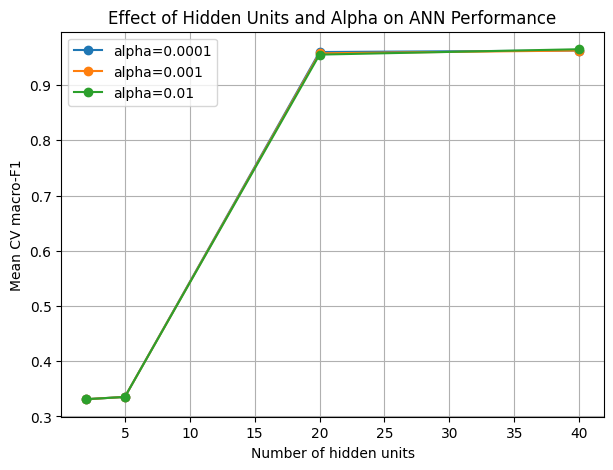

In [11]:
plt.figure(figsize=(7, 5))

for_alpha_values = sorted(ann_cv_df["alpha"].unique())

for alpha in for_alpha_values:
    subset = ann_cv_df[ann_cv_df["alpha"] == alpha]
    plt.plot(
        subset["hidden_units"],
        subset["mean_cv_macro_f1"],
        marker="o",
        label=f"alpha={alpha}"
    )

plt.xlabel("Number of hidden units")
plt.ylabel("Mean CV macro-F1")
plt.title("Effect of Hidden Units and Alpha on ANN Performance")
plt.legend()
plt.grid(True)
plt.show()

## 7. Train the final ANN model

After selecting the best hyperparameters using cross-validation, the final ANN model is trained on the full training set.

The test set is used only for final evaluation.

In [12]:
best_ann_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=2000)),
    ("ann", MLPClassifier(
        hidden_layer_sizes=(best_h,),
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        alpha=best_alpha,
        max_iter=500,
        early_stopping=True,
        random_state=42
    ))
])

best_ann_pipeline.fit(X_train_text, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('ann', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


## 8. Evaluate the final ANN model on the test set

The final model is evaluated using macro F1-score and a classification report.

In [13]:
y_pred_ann = best_ann_pipeline.predict(X_test_text)

ann_test_f1 = f1_score(y_test, y_pred_ann, average="macro")

print("ANN test macro-F1:", ann_test_f1)
print()
print(classification_report(
    y_test,
    y_pred_ann,
    target_names=encoder.classes_
))

ANN test macro-F1: 0.9903732631005359

               precision    recall  f1-score   support

entertainment       1.00      0.98      0.99        61
         tech       0.98      1.00      0.99        45

     accuracy                           0.99       106
    macro avg       0.99      0.99      0.99       106
 weighted avg       0.99      0.99      0.99       106



In [14]:
cm = confusion_matrix(y_test, y_pred_ann)

cm_df = pd.DataFrame(
    cm,
    index=[f"Actual {label}" for label in encoder.classes_],
    columns=[f"Predicted {label}" for label in encoder.classes_]
)

cm_df

,Predicted entertainment,Predicted tech
Actual entertainment,60,1
Actual tech,0,45


## 9. ANN results summary

The ANN model was trained using TF-IDF features and a one-hidden-layer neural network.  
The number of hidden units and the L2 regularisation parameter `alpha` were tuned using 5-fold stratified cross-validation.

The best ANN configuration was:
- hidden units: 40
- alpha: 0.01
- mean cross-validation macro-F1: 0.9650
- test macro-F1: 0.9904

The results show that very small hidden layers, such as 2 or 5 hidden units, underfit the text classification task and achieved low macro-F1 scores.  
When the number of hidden units increased to 20 or 40, the ANN achieved much better performance.  
This suggests that the model needed sufficient hidden-layer capacity to learn useful patterns from the TF-IDF features.

The regularisation parameter `alpha` had a smaller effect than hidden layer size in this experiment.  
The best result was obtained with `alpha = 0.01`, suggesting that a moderate amount of L2 regularisation helped the model generalise well.

Overall, the ANN achieved strong classification performance on the BBC news dataset.  
Because ANN models can fit the training data very well, cross-validation and final test macro F1-score are more reliable indicators of generalisation performance than training performance alone.